In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import warnings 


warnings.filterwarnings("ignore")

In [4]:
#loading the summary csv file
df = pd.read_csv("../results/dataset_summary.csv")

print(df.head())
print(df.columns.tolist())


   task_id dataset_name                suite_name       task_type  n_samples  \
0   361055       credit  numerical_classification  classification      16714   
1   361056   california  numerical_classification  classification      20634   
2   361057         wine  numerical_classification  classification       2554   
3   361060  electricity  numerical_classification  classification      38474   
4   361061    covertype  numerical_classification  classification     566602   

   n_features  n_categorical  n_numerical  n_classes  has_missing  
0          10              0           10        2.0        False  
1           8              0            8        2.0        False  
2          11              0           11        2.0        False  
3           7              0            7        2.0        False  
4          10              0           10        2.0        False  
['task_id', 'dataset_name', 'suite_name', 'task_type', 'n_samples', 'n_features', 'n_categorical', 'n_numerical

In [5]:
# Clean, minimal plot style
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
})

In [6]:
#dataset Overview Table 
overview = df[[
    'dataset_name', 'suite_name', 'task_type',
    'n_samples', 'n_features', 'n_categorical',
    'n_numerical', 'n_classes', 'has_missing'
]].copy()

overview = overview.sort_values(
    ['suite_name', 'n_samples'],
    ascending=[True, False]
).reset_index(drop=True)

print(overview.to_string())

                           dataset_name                  suite_name       task_type  n_samples  n_features  n_categorical  n_numerical  n_classes  has_missing
0                             covertype  categorical_classification  classification     423680          54             44           10        2.0        False
1                           road-safety  categorical_classification  classification     111762          32              3           29        2.0        False
2                           electricity  categorical_classification  classification      38474           8              1            7        2.0        False
3                               compass  categorical_classification  classification      16644          17              9            8        2.0        False
4                         eye_movements  categorical_classification  classification       7608          23              3           20        2.0        False
5                    KDDCup09_upselling  categ

suite_name
numerical_regression          20
numerical_classification      15
categorical_regression        13
categorical_classification     7
Name: count, dtype: int64


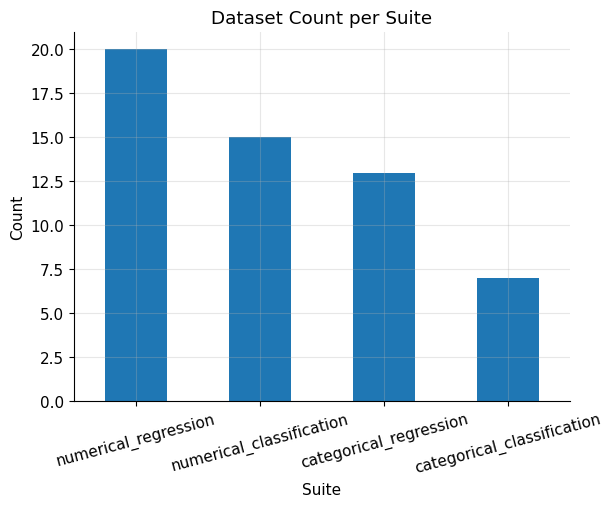

In [7]:
#suite and task type distribution

# The paper expects: 15 numerical_clf, 20 numerical_reg, 7 categorical_clf, 13 categorical_reg.

suite_counts = df['suite_name'].value_counts()
print(suite_counts)

# Simple bar chart to visualize the distribution
suite_counts.plot(kind='bar')
plt.title('Dataset Count per Suite')
plt.xlabel('Suite')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.savefig('../results/suite_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

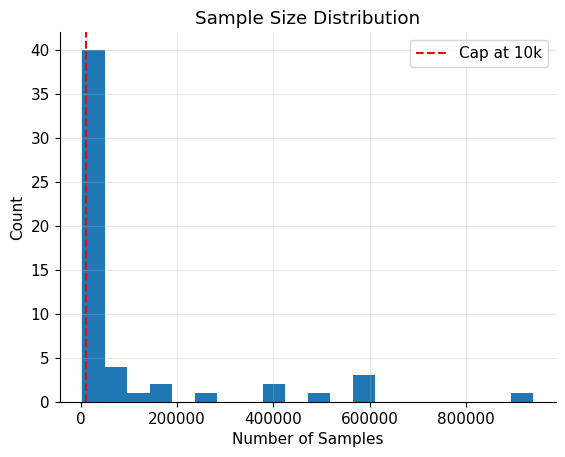

count        55.0
mean     100002.0
std      196443.0
min        2554.0
25%        9483.0
50%       17379.0
75%       53940.0
max      940160.0
Name: n_samples, dtype: float64

Datasets above 10,000 samples (need capping): 41


In [8]:
# Sample size distribution

df['n_samples'].hist(bins=20)
plt.axvline(10000, color='red', linestyle='--', label='Cap at 10k')
plt.title('Sample Size Distribution')
plt.xlabel('Number of Samples')
plt.ylabel('Count')
plt.legend()
plt.savefig('../results/sample_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(df['n_samples'].describe().round(0))
print(f"\nDatasets above 10,000 samples (need capping): {(df['n_samples'] > 10000).sum()}")

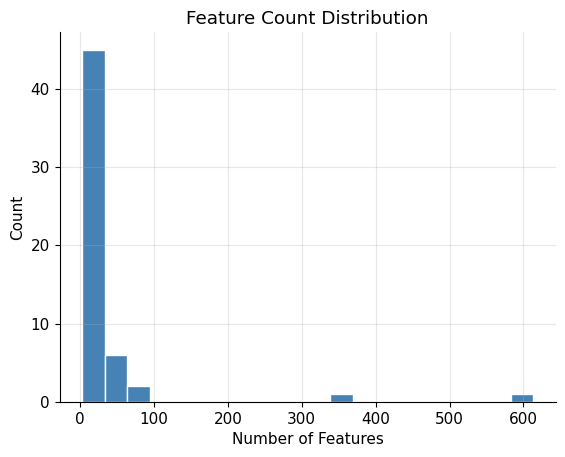

       n_features  dim_ratio
count     55.0000    55.0000
mean      37.0909     0.0042
std       93.3683     0.0153
min        3.0000     0.0000
25%        8.0000     0.0002
50%       12.0000     0.0007
75%       25.0000     0.0017
max      613.0000     0.0853

All datasets below d/n < 0.10: True
Max d/n ratio: 0.0853


In [9]:
#Feature Count and Dimensionality Ratio

# Compute d/n ratio — measures how wide the dataset is relative to its size.
# The paper requires this to be below 0.10 for all datasets.
df['dim_ratio'] = df['n_features'] / df['n_samples']

# Look at the spread of feature counts across all datasets
df['n_features'].hist(bins=20, color='steelblue', edgecolor='white')
plt.title('Feature Count Distribution')
plt.xlabel('Number of Features')
plt.ylabel('Count')
plt.savefig('../results/feature_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Confirm the paper's dimensionality requirement holds for all datasets
print(df[['n_features', 'dim_ratio']].describe().round(4))
print(f"\nAll datasets below d/n < 0.10: {(df['dim_ratio'] < 0.10).all()}")
print(f"Max d/n ratio: {df['dim_ratio'].max():.4f}")

                       dataset_name  n_features  n_categorical  n_numerical  pct_categorical
Mercedes_Benz_Greener_Manufacturing         359            359            0       100.000000
                          covertype          54             44           10        81.481481
                analcatdata_supreme           7              5            2        71.428571
       SGEMM_GPU_kernel_performance           9              6            3        66.666667
                                 rl          12              7            5        58.333333
                       black_friday           9              5            4        55.555556
                            compass          17              9            8        52.941176
      particulate-matter-ukair-2017           6              3            3        50.000000
                Bike_Sharing_Demand          11              5            6        45.454545
            nyc-taxi-green-dec-2016          16              7        

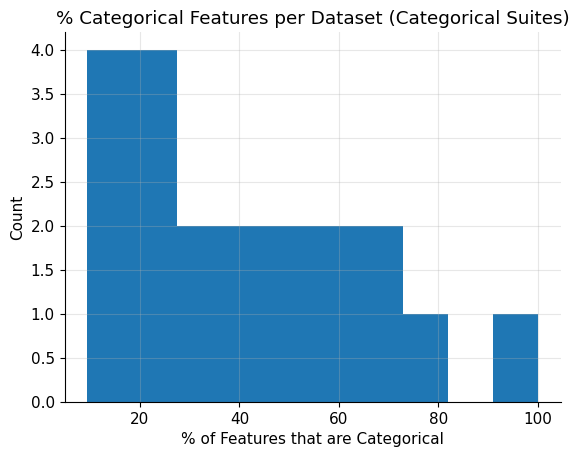

In [10]:
# Categorical Feature Analysis

# Focus only on the categorical suites
cat_df = df[df['suite_name'].str.contains('categorical')].copy()

# What fraction of features are categorical in each dataset?
cat_df['pct_categorical'] = cat_df['n_categorical'] / cat_df['n_features'] * 100

# Look at the breakdown per dataset
print(cat_df[['dataset_name', 'n_features', 'n_categorical', 'n_numerical', 'pct_categorical']]
      .sort_values('pct_categorical', ascending=False)
      .to_string(index=False))

# Plot the distribution of categorical feature percentages
cat_df['pct_categorical'].hist(bins=10)
plt.title('% Categorical Features per Dataset (Categorical Suites)')
plt.xlabel('% of Features that are Categorical')
plt.ylabel('Count')
plt.savefig('../results/categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Group datasets by size and feature count.
# These bucket boundaries are chosen to roughly split the datasets into thirds.

def size_bucket(n):
    if n < 10000:  return 'small (<10k)'
    if n < 50000:  return 'medium (10k-50k)'
    return                'large (>50k)'

def feature_bucket(f):
    if f < 20:   return 'low (<20)'
    if f < 100:  return 'medium (20-100)'
    return               'high (>100)'

df['size_bucket']    = df['n_samples'].apply(size_bucket)
df['feature_bucket'] = df['n_features'].apply(feature_bucket)

# Check how datasets are distributed across buckets
print("Size buckets:")
print(df['size_bucket'].value_counts())

print("\nFeature buckets:")
print(df['feature_bucket'].value_counts())

# Save the enriched summary — this is what all future scripts will use
df.to_csv('../results/dataset_summary_enriched.csv', index=False)

Size buckets:
size_bucket
medium (10k-50k)    26
large (>50k)        15
small (<10k)        14
Name: count, dtype: int64

Feature buckets:
feature_bucket
low (<20)          36
medium (20-100)    17
high (>100)         2
Name: count, dtype: int64
